Training images: 60000
Test images: 10000
{(5, (10, 20, 40, 40, 40)), (3, (10, 20, 20)), (4, (10, 20, 40, 40)), (5, (10, 10, 10, 10, 10)), (2, (20, 40)), (4, (10, 20, 40, 80)), (5, (20, 40, 80, 160, 200)), (1, (200,)), (5, (10, 20, 20, 20, 20)), (3, (10, 10, 10)), (2, (10, 10)), (3, (20, 40, 80)), (4, (20, 40, 80, 160)), (1, (160,)), (2, (80, 160)), (2, (40, 80)), (2, (160, 200)), (3, (80, 160, 200)), (2, (10, 20)), (3, (40, 80, 160)), (4, (10, 10, 10, 10)), (1, (40,)), (1, (80,)), (1, (20,)), (5, (10, 20, 40, 80, 160)), (4, (10, 20, 20, 20)), (3, (10, 20, 40)), (1, (10,)), (4, (40, 80, 160, 200)), (5, (10, 20, 40, 80, 80))}


currently exploring model(n= 5,m= [10, 20, 40, 40, 40])
Epoch 1/5 — Loss: 0.7628
Epoch 2/5 — Loss: 0.3658
Epoch 3/5 — Loss: 0.2976
Epoch 4/5 — Loss: 0.2644
Epoch 5/5 — Loss: 0.2424

Final test accuracy for model(n= 5,m= [10, 20, 40, 40, 40]) : 92.27%
accuracy drop for model(n= 5,m= [10, 20, 40, 40, 40]) : 7.73%
parameter count for model(n= 5,m= [10, 20, 40, 40, 4

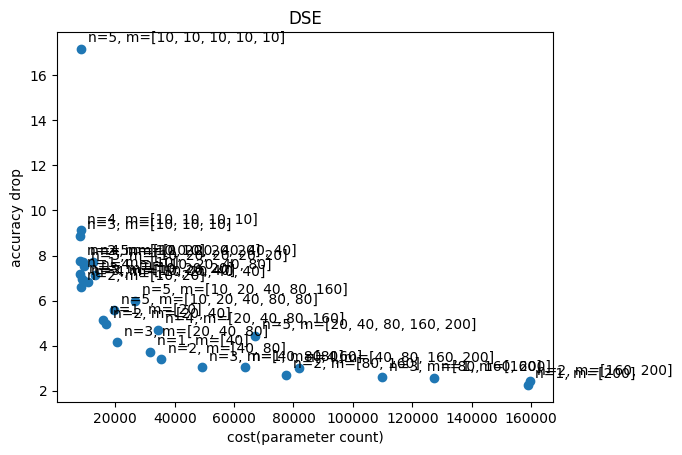

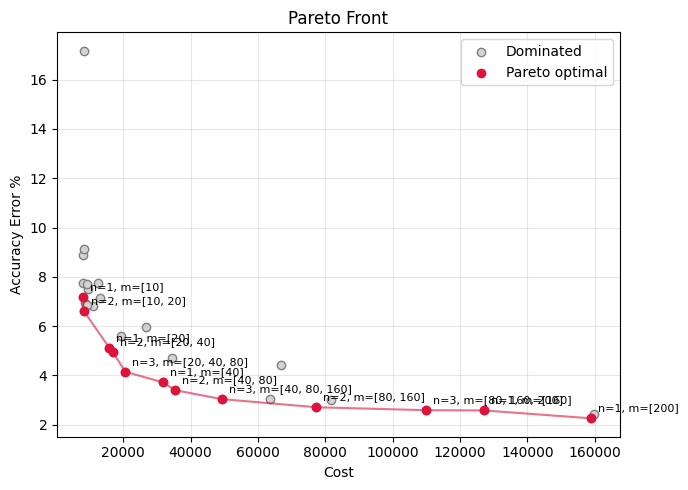

In [ ]:
##trying to optimize code length
#the working code
# ============================================================
# neural network — training on handwritten digits (MNIST)
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Get the training images (MNIST downloads automatically)
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor()  # converts each image into numbers PyTorch can use
])

train_data = datasets.MNIST(
    root="./data",       # where to save the downloaded images
    train=True,           # use the training set (60,000 images)
    download=True,        # download it if not already saved
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,           # use the test set (10,000 images) to check accuracy
    download=True,
    transform=transform
)

# DataLoader feeds images to the network in small batches (64 at a time)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Training images: {len(train_data)}")
print(f"Test images: {len(test_data)}")

# ------------------------------------------------------------
# Define the network
# ------------------------------------------------------------
class parameterized_nn(nn.Module):
    def __init__(self , n , m_array_per_nn , input_size=784 , output_size=10):

      #n is number of hidden layers , m is nodes per hidden layer
        super().__init__()

        m_array_per_nn = np.asarray(m_array_per_nn)

        layers_array = []
        layer_in_size = input_size

        #i wnat a for loop bec n is variable
        for i in range(n):
          layers_array.append(nn.Linear(layer_in_size , m_array_per_nn[i]))
          layer_in_size = m_array_per_nn[i]

        self.hidden_layers = nn.ModuleList(layers_array)
        self.output_layer = nn.Linear(layer_in_size,output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)        # flatten 28x28 image into 784 numbers
        for layer in self.hidden_layers:
          x = torch.relu(layer(x))      # weighted sum + ReLU activation

        return self.output_layer(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

##the bounded design space
n_array = [1,2,3,4,5]
m_array = [[10],[10,20],[10,20,40],[10,20,40,80],[10,20,40,80,160],[10,20,40,80,160,200]]

accuracy_array = []
accuracy_drop_array = []
parameter_count_array = []

points_array = []

seen = set()                                   # sets doesn't allow duplications

for n in n_array:
  for m in m_array:
    if len(m) < n:
      m = list(m) + [m[-1]] * (n - len(m))
      cfg = (n, tuple(m))                        # tuples can go in a set, lists can't
      if cfg in seen:
        continue                                 # already trained this one, skip
      seen.add(cfg)

    elif len(m) > n:
      for b in range(len(m) - n + 1):
        mm = m[b:n+b]

        cfg = (n, tuple(mm))                        # tuples can go in a set, lists can't
        if cfg in seen:
          continue                                 # already trained this one, skip
        seen.add(cfg)

print(seen)
        ####################################################################################
for value in seen:
  (n , mm) = value
  mm = list(mm)
  model = parameterized_nn(n,mm)

  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# Train the network
# must be the same across trials
# ------------------------------------------------------------
  epochs = 5  # how many times we loop over the entire dataset 100 as the paper
  print(f"\n\ncurrently exploring model(n= {n},m= {mm})")
  for epoch in range(epochs):
      model.train()
      total_loss = 0

      for images, labels in train_loader:
          optimizer.zero_grad()             # clear old gradients
          outputs = model(images)           # forward pass
          loss = loss_fn(outputs, labels)   # compute how wrong we are
          loss.backward()                   # backpropagation (compute gradients)
          optimizer.step()                  # gradient descent (update weights)

          total_loss += loss.item()

      avg_loss = total_loss / len(train_loader)
      print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

  # ------------------------------------------------------------
  # Test how well it learned
  # ------------------------------------------------------------
  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():  # no need to track gradients when just testing
      for images, labels in test_loader:
          outputs = model(images)
          predictions = torch.argmax(outputs, dim=1)  # pick the highest-scoring digit
          correct += (predictions == labels).sum().item()
          total += labels.size(0)

  accuracy = 100 * correct / total
  accuracy_drop = 100 - accuracy

  accuracy_array.append(accuracy)
  accuracy_drop_array.append(accuracy_drop)

  points_array.append((n,mm))
  print(f"\nFinal test accuracy for model(n= {n},m= {mm}) : {accuracy:.2f}%")
  print(f"accuracy drop for model(n= {n},m= {mm}) : {accuracy_drop:.2f}%")
  print(f"parameter count for model(n= {n},m= {mm}): {count_parameters(model)}")

  parameter_count_array.append(count_parameters(model))
        ####################################################################################
pareto_array = np.column_stack((parameter_count_array,accuracy_drop_array))
print(pareto_array)
plt.scatter(parameter_count_array, accuracy_drop_array)


for i in range(len(parameter_count_array)):
    u , o = points_array[i]

    plt.annotate(
        f"n={u}, m={o}",
        (parameter_count_array[i], accuracy_drop_array[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )


plt.xlabel("cost(parameter count)")
plt.ylabel("accuracy drop")
plt.title("DSE")
#print(model)
plt.show()
#print(f"\nmaximum accuracy = {max(accuracy_array)}")



######################################
def pareto_front(points, minimize=(True, True)):
    """Return a boolean mask of non-dominated points.

    points   : (N, 2) array of objective values
    minimize : per-objective flag; True = smaller is better, False = larger is better
    """
    pts = np.asarray(points, dtype=float).copy()
    #print(pts)
    # Flip signs so every objective becomes "minimize"
    for i, m in enumerate(minimize):
        if not m:
            pts[:, i] = -pts[:, i]

    n = len(pts)
    is_optimal = np.ones(n, dtype=bool)
    for i in range(n):
        # Point j dominates i if it is <= in all objectives and < in at least one
        dominated = np.all(pts <= pts[i], axis=1) & np.any(pts < pts[i], axis=1)
        if dominated.any():
            is_optimal[i] = False
    return is_optimal


def plot_pareto(points, minimize=(True, True), labels=("Objective 1", "Objective 2")):
    points = np.asarray(points)
    mask = pareto_front(points, minimize)
    front = points[mask]

    # Sort front by first objective so the line connects neatly
    front = front[np.argsort(front[:, 0])]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(*points[~mask].T, c="lightgray", edgecolor="gray", label="Dominated") #Dominated
    ax.scatter(*front.T, c="crimson", zorder=3, label="Pareto optimal")  #pareto
    #ax.step(front[:, 0], front[:, 1], where="post", c="crimson", alpha=0.6)
    ax.plot(front[:, 0], front[:, 1], c="crimson", alpha=0.6, marker="o")

    for i in np.where(mask)[0]:
      u, o = points_array[i]
      ax.annotate(f"n={u}, m={o}",
      (points[i, 0], points[i, 1]),
      xytext=(5, 5), textcoords="offset points", fontsize=8)

    ax.set_xlabel(labels[0])
    ax.set_ylabel(labels[1])
    ax.set_title("Pareto Front")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_pareto(pareto_array, minimize=(True, True), labels=("Cost", "Accuracy Error %"))
